## Iris clustering

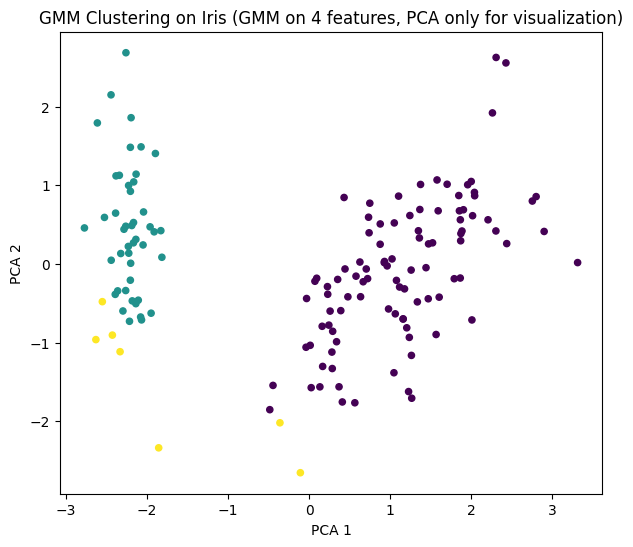

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Tải dữ liệu Iris
iris = load_iris()
X = iris.data        # dùng cả 4 thuộc tính

# 2. Chuẩn hóa
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Huấn luyện GMM trên dữ liệu 4 chiều
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X_scaled)
labels = gmm.predict(X_scaled)

# 4. PCA chỉ để giảm còn 2D phục vụ vẽ hình
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 5. Vẽ scatter trên không gian PCA nhưng nhãn lấy từ GMM 4D
plt.figure(figsize=(7, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=20)
plt.title("GMM Clustering on Iris (GMM on 4 features, PCA only for visualization)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

## Choose k with BIC and AIC

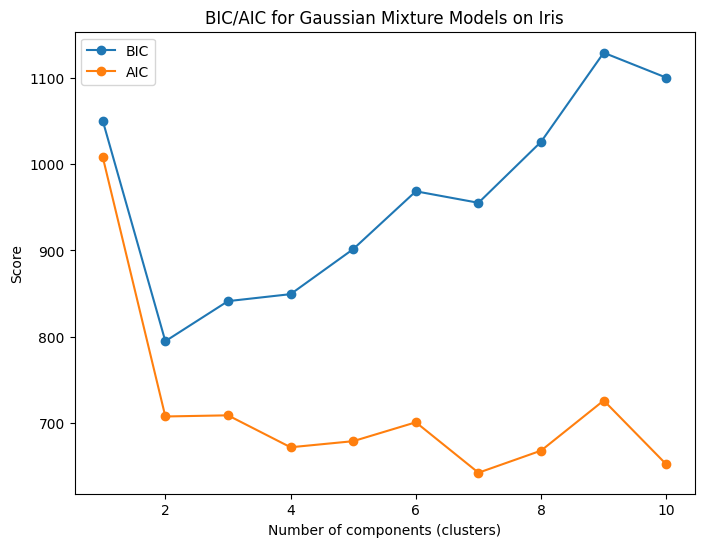

Best number of clusters by BIC: 2
Best number of clusters by AIC: 7


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X = iris.data     # dùng cả 4 thuộc tính

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_components_range = range(1, 11)

bics = []
aics = []

for k in n_components_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    bics.append(gmm.bic(X_scaled))
    aics.append(gmm.aic(X_scaled))

plt.figure(figsize=(8, 6))
plt.plot(n_components_range, bics, marker='o', label='BIC')
plt.plot(n_components_range, aics, marker='o', label='AIC')
plt.xlabel("Number of components (clusters)")
plt.ylabel("Score")
plt.title("BIC/AIC for Gaussian Mixture Models on Iris")
plt.legend()
plt.show()

best_k_bic = n_components_range[np.argmin(bics)]
best_k_aic = n_components_range[np.argmin(aics)]

print("Best number of clusters by BIC:", best_k_bic)
print("Best number of clusters by AIC:", best_k_aic)
